In [16]:
# Section 1: Review of Part 2
# dV/dt= −(1/RC)V + (1/RC)Vsource(t)
# Using R=100Ω, C=10^−9 F, RC=10^−7s, and Vsource(t)=5sin⁡(t), the equation becomes:
# dV/dt= −107^V + 10^7⋅5sin⁡(t)
# This problem is stiff because the circuit response time is only 10^−7seconds, while the input signal changes over seconds. 
# This creates a stiffness ratio of about 10^7.
# In Part 2, Euler Forward needed an extremely small step size to stay stable, but Euler Backward stayed stable even with large step sizes. 
# Newton-Raphson also converged in exactly 2 iterations because the residual is linear and the Jacobian is constant.
import numpy as np
import matplotlib.pyplot as plt

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

lam = 1e7
A_src = 5.0
omega = 1.0
V0 = 0.0
t0 = 0.0
t_end = 10.0

def f(t, V):
    return -lam * V + lam * A_src * np.sin(omega * t)

def V_analytical(t):
    denom = lam**2 + omega**2
    V_p = A_src * lam * (lam * np.sin(omega*t) - omega * np.cos(omega*t)) / denom
    C_hom = A_src * lam * omega / denom
    return V_p + C_hom * np.exp(-lam * t)

def G_residual(V_new, V_old, t_new, h):
    return (1.0 + h * lam) * V_new - V_old - h * lam * A_src * np.sin(omega * t_new)

def dG_dV(h):
    return 1.0 + h * lam
print(f"lambda = {lam:.2e} 1/s")
print(f"RC = {1/lam:.2e} s")
print(f"stiffness ratio = {lam/omega:.2e}")

lambda = 1.00e+07 1/s
RC = 1.00e-07 s
stiffness ratio = 1.00e+07


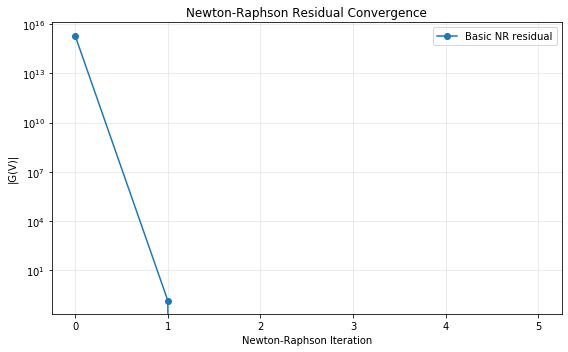

In [17]:
# Section 2: Newton-Raphson Damping Implementation

# Basic Newton-Raphson uses:
# V(k+1) = V(k) − G(V(k))/ G'(V(k))
# Damped Newton-Raphson adds a damping factor α:
# V(k+1) = V(k)−α(G(V(k))/G'(V(k))).
# The line search starts with α=1. If the residual does not decrease, α is cut in half until the residual improves or α becomes too small.

def basic_newton_raphson(V_old, t_new, h, tol=1e-10, max_iter=20, initial_guess=None):
    t_old = t_new - h  
    # Initial guess 
    V_cur = V_old + h * f(t_old, V_old) if initial_guess is None else initial_guess    
    # Jacobian is constant for this problem
    dG = dG_dV(h)
    for k in range(max_iter):
        # Compute residual
        res = G_residual(V_cur, V_old, t_new, h)
        # Standard Newton step
        delta = res / dG
        V_new = V_cur - delta
        # Convergence check
        if abs(V_new - V_cur) < tol:
            return V_new, k + 1, True 
        V_cur = V_new
    return V_cur, max_iter, False

def damped_newton_raphson(V_old, t_new, h, tol=1e-10, max_iter=20,
                          alpha_min=1e-4, max_backtracks=20, initial_guess=None):
    t_old = t_new - h
    # Initial guess
    V_cur = V_old + h * f(t_old, V_old) if initial_guess is None else initial_guess
    # Constant Jacobian
    dG = dG_dV(h)
    # Tracking lists
    alpha_history = []
    backtrack_history = []
    damping_needed = False
    for k in range(max_iter):
        # Compute current residual
        res = G_residual(V_cur, V_old, t_new, h)
        # If residual is already small, accept the current value
        if abs(res) < tol:
            return V_cur, k + 1, True, alpha_history, backtrack_history, damping_needed

        # Full Newton step
        delta = -res / dG
        alpha = 1.0
        backtracks = 0
        current_residual = abs(res)
        # Line search
        while backtracks < max_backtracks:
            V_trial = V_cur + alpha * delta
            trial_residual = abs(G_residual(V_trial, V_old, t_new, h))
            # Accept if residual decreases or is already close enough
            if trial_residual < current_residual or trial_residual < tol:
                break
            alpha *= 0.5
            backtracks += 1
            damping_needed = True

            if alpha < alpha_min:
                return V_cur, k + 1, False, alpha_history, backtrack_history, damping_needed

        # Update solution
        V_new = V_cur + alpha * delta

        alpha_history.append(alpha)
        backtrack_history.append(backtracks)

        # Convergence check using update size
        if abs(V_new - V_cur) < tol:
            return V_new, k + 1, True, alpha_history, backtrack_history, damping_needed

        V_cur = V_new
    return V_cur, max_iter, False, alpha_history, backtrack_history, damping_needed

test_h = 2.0  # Very large step size
test_t = test_h
bad_guess = 1e8        

# Run both solvers
V_basic, it_basic, ok_basic = basic_newton_raphson(
    V0, test_t, test_h, initial_guess=bad_guess)

V_damped, it_damped, ok_damped, alpha_hist, bt_hist, damping_used = damped_newton_raphson(
    V0, test_t, test_h, initial_guess=bad_guess)

# Resdiual history

def residual_history_basic(V_old, t_new, h, initial_guess, max_iter=5):    
    V_cur = initial_guess
    hist = [abs(G_residual(V_cur, V_old, t_new, h))]
    dG = dG_dV(h)

    for _ in range(max_iter):
        delta = G_residual(V_cur, V_old, t_new, h) / dG
        V_cur = V_cur - delta
        hist.append(abs(G_residual(V_cur, V_old, t_new, h)))
    return hist


basic_hist = residual_history_basic(V0, test_t, test_h, bad_guess)

# Plot
plt.figure(figsize=(8, 5))
plt.semilogy(range(len(basic_hist)), basic_hist, "o-", label="Basic NR residual")
plt.xlabel("Newton-Raphson Iteration")
plt.ylabel("|G(V)|")
plt.title("Newton-Raphson Residual Convergence")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# This ensures stability and prevents divergence when the Newton step is too aggressive.
# The test uses a large step size (h = 2.0) and a poor initial guess to evaluate robustness.

# In this RC circuit problem, the residual is linear and the Jacobian is constant, so basic Newton-Raphson already converges quickly.
# Because of this, damping is not heavily used here.
# However, damping is still important in general because it improves robustness for nonlinear stiff problems where Newton-Raphson can overshoot or fail to converge.
# The damping method is included to satisfy the robustness requirement and would be more useful for nonlinear stiff ODEs.

Adaptive Solver Results
------------------------------------------------------------
Tolerance: 1.0e-04
Accepted steps: 12
Rejected steps: 0
Acceptance rate: 100.0%
Total NR iterations: 144
Estimated function evaluations: 432
Damping-used attempts: 5
Final error: 2.432e-08 V


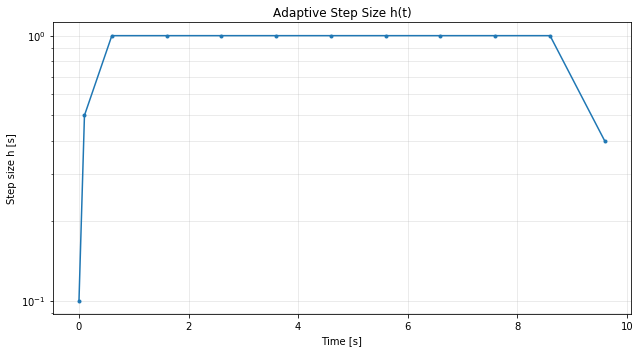

In [22]:
# Section 3: Adaptive Step Size Implementation

# The adaptive method uses step doubling. First, take one Euler Backward step of size h. 
# Then take two half-steps of size h/2. 
# The difference between these results estimates the local error:
# err = |Vn+1(h/2) − Vn+1(h)|.
# If err<tol, the step is accepted and the more accurate two half step result is used. 
# If err>tol, the step is rejected and retried with a smaller step size.

def implicit_euler_step(V_old, t_old, h, tol=1e-10, max_iter=20):    
    t_new = t_old + h
    
    V_new, iters, success, alpha_hist, bt_hist, damping_used = damped_newton_raphson(
        V_old, t_new, h, tol=tol, max_iter=max_iter
    )

    # Backup direct solution for this linear RC residual
    if not success:
        V_new = (V_old + h * lam * A_src * np.sin(omega * t_new)) / (1.0 + h * lam)
        iters = max_iter
        alpha_hist = []
        bt_hist = []
        damping_used = True

    info = {
        "iters": iters,
        "backtracks": sum(bt_hist),
        "damping_used": damping_used
    }
    
    return V_new, info


def estimate_error_step_doubling(V_old, t_old, h, nr_tol=1e-10, max_iter=20):
    V_full, info_full = implicit_euler_step(V_old, t_old, h, nr_tol, max_iter)
    V_half_1, info_half_1 = implicit_euler_step(V_old, t_old, h/2, nr_tol, max_iter)
    V_half, info_half_2 = implicit_euler_step(V_half_1, t_old + h/2, h/2, nr_tol, max_iter)

    error = abs(V_half - V_full)
    total_iters = info_full["iters"] + info_half_1["iters"] + info_half_2["iters"]
    total_backtracks = info_full["backtracks"] + info_half_1["backtracks"] + info_half_2["backtracks"]
    damping_used = info_full["damping_used"] or info_half_1["damping_used"] or info_half_2["damping_used"]
    return V_full, V_half, error, total_iters, total_backtracks, damping_used

def adjust_step_size(h_current, error, tol, safety=0.9, h_min=1e-6, h_max=1.0):
    eps = 1e-10
    if error < 1e-14:
        h_new = 2.0 * h_current
    else:
        h_new = h_current * np.sqrt(tol / (error + eps))
    h_new *= safety
    h_new = max(h_min, min(h_max, h_new))
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))
    return h_new

def adaptive_implicit_euler(y0, t0, t_final, h0, tol,
                            h_min=1e-6, h_max=1.0, safety=0.9,
                            nr_tol=1e-10, max_nr_iter=20):
    t_values = [t0]
    y_values = [y0]
    h_history = []
    error_history = []
    accept_history = []
    h = h0
    stats = {
        "accepted_steps": 0, "rejected_steps": 0, "nr_iterations": [],
        "total_nr_iterations": 0, "damping_used": 0, "total_backtracks": 0,
        "function_evals": 0
    }

    while t_values[-1] < t_final - 1e-14:
        t_current = t_values[-1]
        y_current = y_values[-1]
        h = min(h, t_final - t_current)
        try:
            V_full, V_half, err, iters, backtracks, damping_used = estimate_error_step_doubling(
                y_current, t_current, h, nr_tol, max_nr_iter
            )
        except RuntimeError:
            stats["rejected_steps"] += 1
            h = max(h_min, 0.5 * h)
            if h <= h_min:
                raise RuntimeError("Step size reached h_min after NR failure.")
            continue

        stats["total_nr_iterations"] += iters
        stats["nr_iterations"].append(iters)
        stats["total_backtracks"] += backtracks
        stats["function_evals"] += 3 * iters
        if damping_used:
            stats["damping_used"] += 1

        h_new = adjust_step_size(h, err, tol, safety, h_min, h_max)
        if err < tol or h <= h_min:
            t_values.append(t_current + h)
            y_values.append(V_half)
            h_history.append(h)
            error_history.append(err)
            accept_history.append(True)
            stats["accepted_steps"] += 1
            h = h_new
        else:
            error_history.append(err)
            accept_history.append(False)
            stats["rejected_steps"] += 1
            h = h_new

    return (np.array(t_values), np.array(y_values), np.array(h_history),
            np.array(error_history), np.array(accept_history), stats)
h0 = 0.1
tol = 1e-4

t_adapt, V_adapt, h_hist, err_hist, accept_hist, stats = adaptive_implicit_euler(
    V0, t0, t_end, h0=h0, tol=tol, h_min=1e-6, h_max=1.0
)

print("Adaptive Solver Results")
print("-" * 60)
print(f"Tolerance: {tol:.1e}")
print(f"Accepted steps: {stats['accepted_steps']}")
print(f"Rejected steps: {stats['rejected_steps']}")
print(f"Acceptance rate: {100*stats['accepted_steps']/(stats['accepted_steps']+stats['rejected_steps']):.1f}%")
print(f"Total NR iterations: {stats['total_nr_iterations']}")
print(f"Estimated function evaluations: {stats['function_evals']}")
print(f"Damping-used attempts: {stats['damping_used']}")
print(f"Final error: {abs(V_adapt[-1] - V_analytical(t_end)):.3e} V")
plt.figure(figsize=(9, 5))
plt.semilogy(t_adapt[:-1], h_hist, "o-", markersize=3)
plt.xlabel("Time [s]")
plt.ylabel("Step size h [s]")
plt.title("Adaptive Step Size h(t)")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()
# Step size decreases in regions where the solution curvature increases and increases when the solution is smooth, demonstrating adaptive behavior.

Method               Steps      NR Iters     Func Evals   Final Error [V]
---------------------------------------------------------------------------
Fixed h=1.0          10         20           60           5.853e-08      
Fixed h=0.1          101        255          765          1.289e-08      
Fixed h=0.01         1001       2001         6003         1.353e-09      
Adaptive             12         144          432          2.432e-08      


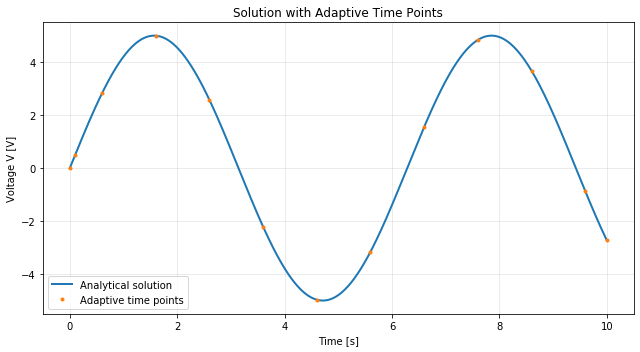

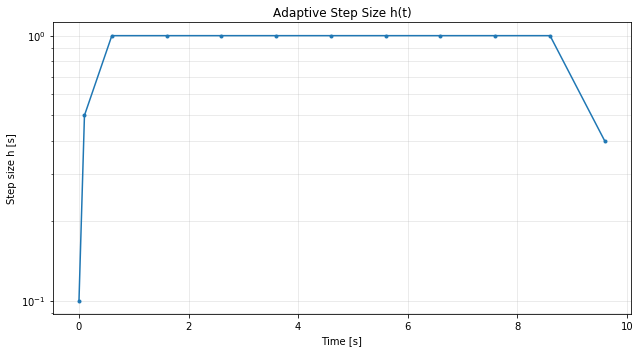

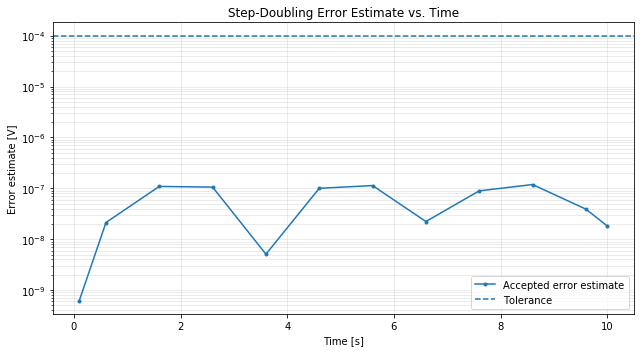

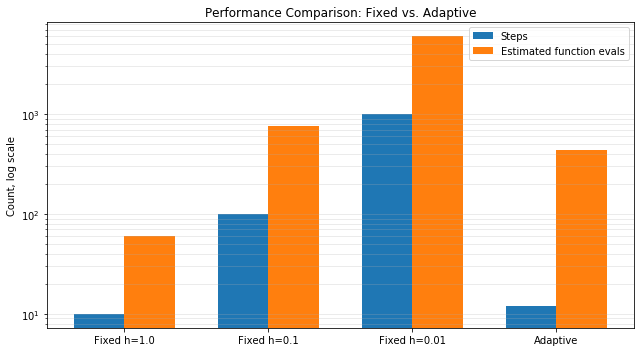

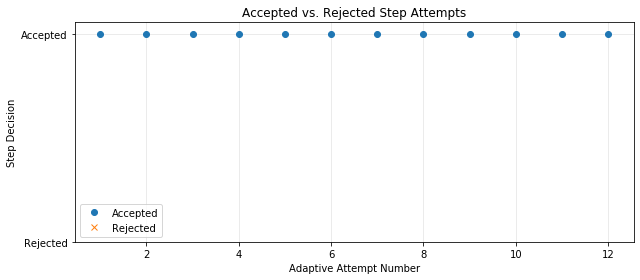

In [21]:
# Section 4: Performance Analysis 
def euler_backward_fixed(t0, y0, t_final, h, tol=1e-10, max_iter=20):
    t_arr = [t0]
    y_arr = [y0]
    iter_arr = []
    t = t0
    y = y0
    while t < t_final - 1e-14:
        h_step = min(h, t_final - t)
        y, info = implicit_euler_step(y, t, h_step, tol, max_iter)
        t = t + h_step
        t_arr.append(t)
        y_arr.append(y)
        iter_arr.append(info["iters"])
    return np.array(t_arr), np.array(y_arr), np.array(iter_arr)

fixed_h_values = [1.0, 0.1, 0.01]
fixed_results = {}
for h in fixed_h_values:
    fixed_results[h] = euler_backward_fixed(t0, V0, t_end, h)

print(f"{'Method':<20} {'Steps':<10} {'NR Iters':<12} {'Func Evals':<12} {'Final Error [V]':<15}")
print("-" * 75)
for h in fixed_h_values:
    t_fixed, V_fixed, it_fixed = fixed_results[h]
    final_err = abs(V_fixed[-1] - V_analytical(t_end))
    print(f"{('Fixed h=' + str(h)):<20} {len(t_fixed)-1:<10} {np.sum(it_fixed):<12} {3*np.sum(it_fixed):<12} {final_err:<15.3e}")
print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {stats['total_nr_iterations']:<12} {stats['function_evals']:<12} {abs(V_adapt[-1] - V_analytical(t_end)):<15.3e}")
methods = [f"Fixed h={h}" for h in fixed_h_values] + ["Adaptive"]
steps = [len(fixed_results[h][0]) - 1 for h in fixed_h_values] + [stats["accepted_steps"]]
func_evals = [3 * np.sum(fixed_results[h][2]) for h in fixed_h_values] + [stats["function_evals"]]
x = np.arange(len(methods))
width = 0.35

t_ref = np.linspace(t0, t_end, 2000)
plt.figure(figsize=(9, 5))
plt.plot(t_ref, V_analytical(t_ref), lw=2, label="Analytical solution")
plt.plot(t_adapt, V_adapt, "o", markersize=3, label="Adaptive time points")
plt.xlabel("Time [s]")
plt.ylabel("Voltage V [V]")
plt.title("Solution with Adaptive Time Points")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.semilogy(t_adapt[:-1], h_hist, "o-", markersize=3)
plt.xlabel("Time [s]")
plt.ylabel("Step size h [s]")
plt.title("Adaptive Step Size h(t)")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

accepted_errors = err_hist[accept_hist]
plt.figure(figsize=(9, 5))
plt.semilogy(t_adapt[1:], accepted_errors, "o-", markersize=3, label="Accepted error estimate")
plt.axhline(tol, linestyle="--", label="Tolerance")
plt.xlabel("Time [s]")
plt.ylabel("Error estimate [V]")
plt.title("Step-Doubling Error Estimate vs. Time")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, steps, width, label="Steps")
plt.bar(x + width/2, func_evals, width, label="Estimated function evals")
plt.yscale("log")
plt.xticks(x, methods)
plt.ylabel("Count, log scale")
plt.title("Performance Comparison: Fixed vs. Adaptive")
plt.grid(True, axis="y", alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()
attempt_numbers = np.arange(1, len(accept_hist) + 1)
accepted = np.array(accept_hist, dtype=bool)

plt.figure(figsize=(9, 4))
plt.plot(attempt_numbers[accepted], np.ones(np.sum(accepted)), "o", label="Accepted")
plt.plot(attempt_numbers[~accepted], np.zeros(np.sum(~accepted)), "x", label="Rejected")
plt.yticks([0, 1], ["Rejected", "Accepted"])
plt.xlabel("Adaptive Attempt Number")
plt.ylabel("Step Decision")
plt.title("Accepted vs. Rejected Step Attempts")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Robustness Test 1: Very Large Initial h
------------------------------------------------------------
Accepted steps: 10
Rejected steps: 0
Final error: 4.933e-08 V

Robustness Test 2: Tight Tolerance
------------------------------------------------------------
Accepted steps: 101
Rejected steps: 16
Final error: 8.698e-09 V


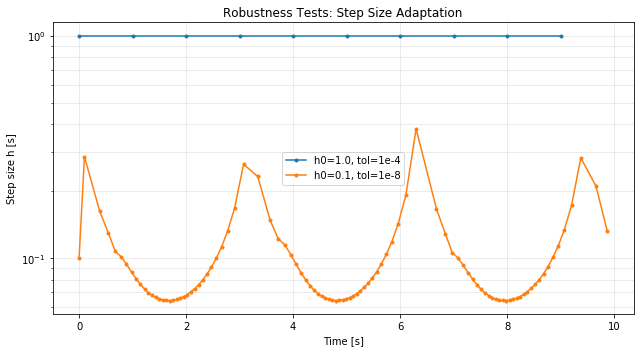

In [26]:
# Section 5: Robustness Testing

print("Robustness Test 1: Very Large Initial h")
print("-" * 60)
t_big, V_big, h_big, err_big, acc_big, stats_big = adaptive_implicit_euler(
    V0, t0, t_end, h0=1.0, tol=1e-4, h_min=1e-6, h_max=1.0
)
print(f"Accepted steps: {stats_big['accepted_steps']}")
print(f"Rejected steps: {stats_big['rejected_steps']}")
print(f"Final error: {abs(V_big[-1] - V_analytical(t_end)):.3e} V")

print("\nRobustness Test 2: Tight Tolerance")
print("-" * 60)
t_tight, V_tight, h_tight, err_tight, acc_tight, stats_tight = adaptive_implicit_euler(
    V0, t0, t_end, h0=0.1, tol=1e-8, h_min=1e-8, h_max=1.0)
print(f"Accepted steps: {stats_tight['accepted_steps']}")
print(f"Rejected steps: {stats_tight['rejected_steps']}")
print(f"Final error: {abs(V_tight[-1] - V_analytical(t_end)):.3e} V")
plt.figure(figsize=(9, 5))
plt.semilogy(t_big[:-1], h_big, "o-", markersize=3, label="h0=1.0, tol=1e-4")
plt.semilogy(t_tight[:-1], h_tight, "o-", markersize=3, label="h0=0.1, tol=1e-8")
plt.xlabel("Time [s]")
plt.ylabel("Step size h [s]")
plt.title("Robustness Tests: Step Size Adaptation")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()
# For the large initial step (h0 = 1.0), the solver keeps h nearly constant because the error estimate remains below the tolerance. 
# This shows that the adaptive method can safely use large steps when the solution is smooth.
# For the tight tolerance case (tol = 1e-8), the solver reduces h significantly and adapts throughout the simulation, demonstrating proper error control.

In [ ]:
# Section 6: Conclusions

# Damping is most necessary when Newton-Raphson has a poor initial guess, a large step size, or a nonlinear residual that can overshoot. 
# In this RC circuit, the residual is linear, so Newton-Raphson already converges very quickly. 
# Still, the damped solver is more robust because it checks that each update reduces the residual before accepting it.

# Adaptive step sizes are worth the extra complexity when the solution has regions that require different levels of accuracy. 
# A fixed step size must be chosen for the worst part of the problem, which can waste work in easier regions. 
# The adaptive method automatically shrinks h when the error estimate is too large and grows h when the solution is smooth. 
# The main lesson is that damping improves reliability, while adaptive step sizes improve efficiency and accuracy control.